<h1 style="color:#ffffff; background-color:#1F4B33; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">Week 5 — Day 2: DBSCAN &amp; Hierarchical Clustering</h1>
<p style="color:#F2C14E; background-color:#2E6B4A; text-align:center; font-weight:bold; font-style:italic; padding:6px 10px; border-radius:6px; margin-top:0; font-size:15px;">Two Alternatives to K-Means That Need No k In Advance</p>


<a id="toc"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>
<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</a></li>
<li><a href="#section1">1. Why K-Means Isn't Always Enough</a></li>
<li><a href="#section2">2. DBSCAN</a></li>
<li><a href="#section3">3. Hierarchical Clustering</a></li>
<li><a href="#section4">4. Choosing the Right Method</a></li>
<li><a href="#section5">5. Common Mistakes to Avoid</a></li>
<li><a href="#section6">6. Quick Reference — Cheat Sheet</a></li>
<li><a href="#section7">7. Hands-On Lab — Comparing Clustering Methods</a></li>
<li><a href="#section8">8. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section9">9. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</h2>
<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Day 1's K-Means needed <code>k</code> chosen in advance and assumes round, similarly-sized clusters. Today's two algorithms remove both assumptions — and we test them on a real clinical dataset, where natural groupings are rarely as clean as a textbook example.
</div>


In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import scipy

print("Pandas version      :", pd.__version__)
print("NumPy version       :", np.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("SciPy version       :", scipy.__version__)

Pandas version      : 2.3.3
NumPy version       : 2.3.5
Scikit-learn version: 1.7.2
SciPy version       : 1.16.3


<a id="section1"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. Why K-Means Isn't Always Enough</h2>
K-Means has real limitations: it requires you to <b>pick <code>k</code> in advance</b>, it assumes clusters are <b>round and similarly sized</b>, and it <b>forces every point into a cluster</b> — even clear outliers. When data has irregular shapes or noise, K-Means gives misleading results. Two alternative algorithms address these weaknesses.

<a id="section2"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. DBSCAN</h2>
<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 Density instead of distance-to-centroid</h3>
<b>DBSCAN</b> (Density-Based Spatial Clustering) groups points that are packed closely together and labels points in sparse regions as <b>noise</b>. It has two key advantages over K-Means: it <b>discovers the number of clusters automatically</b> (no <code>k</code> needed), and it can find <b>arbitrarily shaped</b> clusters while explicitly flagging outliers rather than forcing them into a group.

In [ ]:
from sklearn.cluster import DBSCAN

# db = DBSCAN(eps=0.5, min_samples=5)
# labels = db.fit_predict(X)
# label -1 marks noise / outlier points

print("We will run DBSCAN on the heart-disease dataset in Section 7.")

We will run DBSCAN on the heart-disease dataset in Section 7.


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#2E6B4A; color:#F2C14E;"><th style="padding:8px; text-align:left;">Parameter</th><th style="padding:8px; text-align:left;">Controls</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>eps</code></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">How close two points must be to count as neighbors</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>min_samples</code></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">How many neighbors a point needs to start a dense cluster</td></tr>
</table>
</div>


<a id="section3"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. Hierarchical Clustering</h2>
<b>Hierarchical clustering</b> builds a tree of clusters — starting with every point as its own cluster and repeatedly merging the two closest, until all points join one cluster. The result is visualized as a <b>dendrogram</b>, a tree diagram where you can "cut" at any height to get any number of clusters. It needs no <code>k</code> in advance and shows the <b>nested structure</b> of the data.

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Z = linkage(X, method="ward")
# dendrogram(Z)   # cut the tree at a chosen height to pick clusters

print("We will build a real dendrogram in Section 7.")

We will build a real dendrogram in Section 7.


<a id="section4"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. Choosing the Right Method</h2>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#2E6B4A; color:#F2C14E;"><th style="padding:8px; text-align:left;">Method</th><th style="padding:8px; text-align:left;">Best When</th><th style="padding:8px; text-align:left;">Watch Out For</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">K-Means</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Round, similarly-sized clusters; k roughly known</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Forces outliers into clusters; needs k</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">DBSCAN</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Irregular shapes, noise/outliers present</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Sensitive to eps; struggles with varying densities</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Hierarchical</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">You want nested structure or a dendrogram</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Slow on very large datasets</td></tr>
</table>
</div>


<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> There is no single "best" clustering algorithm — the right choice depends entirely on the <b>shape</b> of the data. Today's Hands-On Lab runs all three on the same dataset so you can see this directly, instead of just reading it in a table.
</div>


<a id="section5"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. Common Mistakes to Avoid</h2>
<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <ul>
<li><b>Using DBSCAN without scaling features first</b> — <code>eps</code> is a distance threshold, so it is just as sensitive to feature scale as K-Means.</li>
<li><b>Picking <code>eps</code> and <code>min_samples</code> blindly</b> — a poor choice can label almost everything as noise, or merge everything into one giant cluster.</li>
<li><b>Treating DBSCAN's noise label (<code>-1</code>) as a real cluster</b> — it means "did not fit any dense region," not a group with shared characteristics.</li>
<li><b>Reading a dendrogram's left-right order as meaningful</b> — only the <b>merge heights</b> carry information; the horizontal order of leaves does not.</li>
<li><b>Defaulting to K-Means without checking the data's shape</b> — irregular or noisy data often needs DBSCAN or hierarchical clustering instead.</li>
</ul>
</div>


<a id="section6"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. Quick Reference — Cheat Sheet</h2>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#2E6B4A; color:#F2C14E;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Import DBSCAN</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>from sklearn.cluster import DBSCAN</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Fit DBSCAN</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>DBSCAN(eps=0.5, min_samples=5).fit_predict(X)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Noise label</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>-1</code> marks a noise / outlier point</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Import hierarchical tools</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>from scipy.cluster.hierarchy import dendrogram, linkage</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Build linkage matrix</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>Z = linkage(X, method="ward")</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Plot dendrogram</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>dendrogram(Z)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Cut into k clusters</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>from scipy.cluster.hierarchy import fcluster</code><br><code>fcluster(Z, k, criterion="maxclust")</code></td></tr>
</table>
</div>


<a id="section7"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Hands-On Lab — Comparing Clustering Methods</h2>
<div style="border-left:5px solid #9B6FD4; background-color:#f3edfb; padding:10px 15px; margin:10px 0; border-radius:4px; color:#4d3475;">
<b>Goal:</b> Run K-Means, DBSCAN, and hierarchical clustering on a real clinical dataset — patient heart health records — compare all three methods side by side, and decide which one best fits this dataset's shape.
</div>


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">7.0 Loading, cleaning, and scaling the dataset</h3>
This lab uses <code>heart.csv</code>, a real heart-failure dataset with 918 patient records. It has a <code>HeartDisease</code> column (0/1), but clustering never sees it — it is used only at the end, as an optional check on whether the clusters happen to line up with diagnosis. We cluster on five numeric clinical features: <code>Age</code>, <code>RestingBP</code>, <code>Cholesterol</code>, <code>MaxHR</code>, and <code>Oldpeak</code>.

In [ ]:
df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <b>Data quality check:</b> this dataset encodes some missing clinical readings as <code>0</code>, which is not a medically real value for <code>RestingBP</code> or <code>Cholesterol</code>. Left as-is, these zeros would badly distort distance-based clustering. We treat them as missing and impute with the median before clustering.
</div>


In [ ]:
clinical_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

print("Zero values found (treated as missing):")
print((df[clinical_features] == 0).sum())

X = df[clinical_features].copy()
for col in ["RestingBP", "Cholesterol"]:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

print()
print("Remaining zeros after cleaning:")
print((X[["RestingBP", "Cholesterol"]] == 0).sum())

Zero values found (treated as missing):
Age              0
RestingBP        1
Cholesterol    172
MaxHR            0
Oldpeak        368
dtype: int64

Remaining zeros after cleaning:
RestingBP      0
Cholesterol    0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (918, 5)


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Run DBSCAN and report clusters and noise points</h3>


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.9, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN found {n_clusters_dbscan} clusters")
print(f"DBSCAN flagged {n_noise} points as noise (out of {len(dbscan_labels)})")

DBSCAN found 2 clusters
DBSCAN flagged 201 points as noise (out of 918)


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Clinical measurements like these rarely form neat, well-separated groups — real patient data is noisy and continuous. If DBSCAN flags a large fraction of patients as noise, that itself is informative: it suggests round, K-Means-style clusters may not be a realistic model of this data. Try adjusting <code>eps</code> — larger merges more points into dense regions, smaller is stricter about what counts as "close."
</div>


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Build a hierarchical clustering dendrogram and choose a cut height</h3>


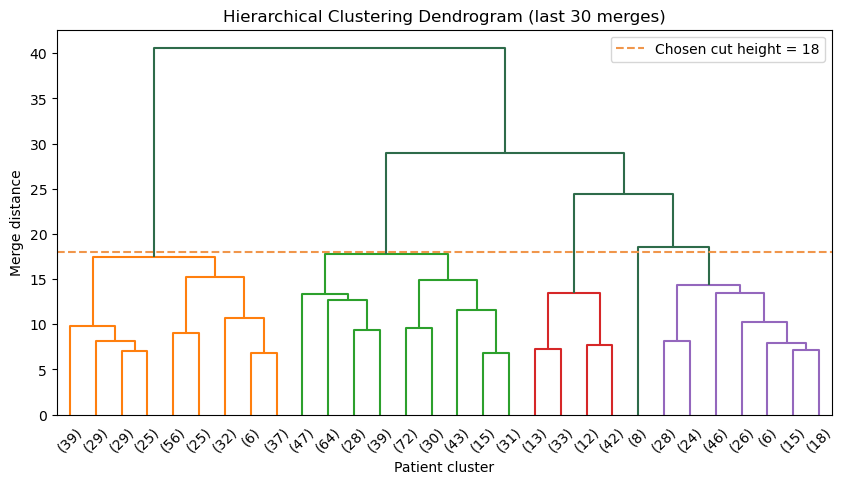

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# truncate_mode keeps the plot readable with 918 patients
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=30, color_threshold=18, above_threshold_color="#2E6B4A")
plt.axhline(y=18, color="#F0964B", linestyle="--", label="Chosen cut height = 18")
plt.title("Hierarchical Clustering Dendrogram (last 30 merges)")
plt.xlabel("Patient cluster")
plt.ylabel("Merge distance")
plt.legend()
plt.show()

In [ ]:
# Cut the full (untruncated) tree at the chosen height to assign cluster labels
cut_height = 18
hierarchical_labels = fcluster(Z, t=cut_height, criterion="distance")
n_clusters_hierarchical = len(set(hierarchical_labels))

print(f"Cutting the dendrogram at height {cut_height} gives {n_clusters_hierarchical} clusters")

Cutting the dendrogram at height 18 gives 5 clusters


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Compare the K-Means, DBSCAN, and hierarchical results on the same data</h3>


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Pick k for K-Means using the silhouette score, the same discipline from Day 1
silhouette_by_k = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    silhouette_by_k[k] = silhouette_score(X_scaled, km.labels_)

best_k = max(silhouette_by_k, key=silhouette_by_k.get)
print("Silhouette score by k:", {k: round(v, 3) for k, v in silhouette_by_k.items()})
print(f"Chosen k for K-Means: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

comparison = pd.DataFrame({
    "Method": [f"K-Means (k={best_k})", "DBSCAN", "Hierarchical"],
    "Clusters found": [
        len(set(kmeans_labels)),
        n_clusters_dbscan,
        n_clusters_hierarchical,
    ],
    "Noise points": [0, n_noise, 0],
})
comparison

Silhouette score by k: {2: 0.218, 3: 0.178, 4: 0.181, 5: 0.187, 6: 0.164}
Chosen k for K-Means: 2


,Method,Clusters found,Noise points
0,K-Means (k=2),2,0
1,DBSCAN,2,201
2,Hierarchical,5,0


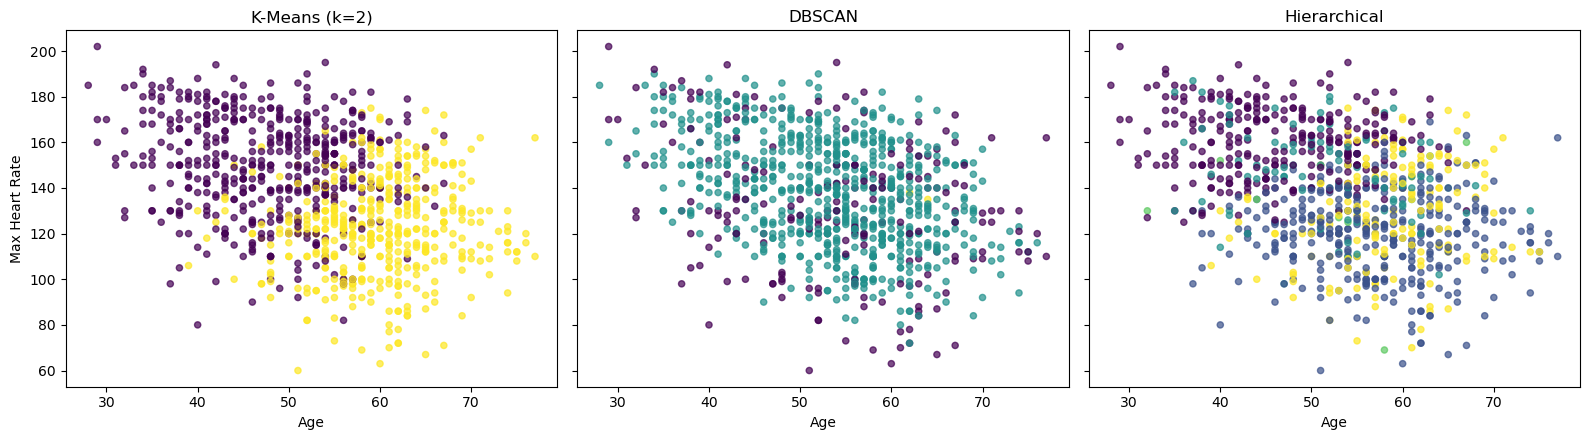

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)

for ax, labels, title in zip(
    axes,
    [kmeans_labels, dbscan_labels, hierarchical_labels],
    [f"K-Means (k={best_k})", "DBSCAN", "Hierarchical"],
):
    scatter = ax.scatter(X["Age"], X["MaxHR"], c=labels, cmap="viridis", s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Age")
axes[0].set_ylabel("Max Heart Rate")
plt.tight_layout()
plt.show()

<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> Look closely at the three scatter plots: K-Means always draws roughly round boundaries between clusters, while DBSCAN and hierarchical clustering are free to follow whatever shape the data actually takes — including leaving sparse points unassigned, in DBSCAN's case.
</div>


In [ ]:
# Optional cross-check: clustering never saw HeartDisease -- does it line up with the clusters anyway?
check = df.copy()
check["KMeans_cluster"] = kmeans_labels

disease_rate_by_cluster = check.groupby("KMeans_cluster")["HeartDisease"].mean().round(2)
print("Heart disease rate by K-Means cluster (label was NOT used for clustering):")
print(disease_rate_by_cluster)

Heart disease rate by K-Means cluster (label was NOT used for clustering):
KMeans_cluster
0    0.35
1    0.77
Name: HeartDisease, dtype: float64


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> This cross-check is purely for interpretation, never for training — the clusters were built from <code>Age</code>, <code>RestingBP</code>, <code>Cholesterol</code>, <code>MaxHR</code>, and <code>Oldpeak</code> alone. If the disease rate still varies noticeably between clusters, it means these five clinical features carry real signal about diagnosis, even with no label used in the clustering itself.
</div>


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — State which method best fits this dataset's shape and why</h3>


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Final Recommendation</b><br> 
For this dataset, I would use K-Means as the simplest baseline because it produced two clusters and the highest silhouette score among the tested k values was obtained at k=2. However, DBSCAN is also useful because it identified 201 points as noise, showing that the dataset contains many observations that do not belong to dense regions.

Hierarchical clustering provides a more detailed nested view of the data, but the five clusters obtained at the selected cut height may be more useful for exploration than for a simple segmentation task.


<a id="section8"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <ul>
<li>Always scale features before DBSCAN or hierarchical clustering, exactly as with K-Means.</li>
<li>Tune <code>eps</code> and <code>min_samples</code> deliberately — try a few values and check how many clusters and noise points result.</li>
<li>Treat DBSCAN's <code>-1</code> noise label as "unassigned," not as its own cluster.</li>
<li>Choose a dendrogram cut height by looking for the <b>tallest vertical gap</b> the cut line can pass through without crossing a merge.</li>
<li>Compare methods on the <b>same scaled data</b> for a fair, apples-to-apples comparison.</li>
</ul>
</div>


<a id="section9"></a>
<h2 style="color:#F2C14E; background-color:#2E6B4A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">9. Summary — What I Learned Today</h2>
<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> <ul>
<li>K-Means has real limits: it needs <code>k</code> chosen in advance, assumes round clusters, and forces every point into a group.</li>
<li><b>DBSCAN</b> groups points by density, discovers the cluster count automatically, and explicitly flags outliers as noise.</li>
<li><b>Hierarchical clustering</b> builds a full tree of nested clusters, visualized as a <b>dendrogram</b> you can cut at any height.</li>
<li>No single method wins on every dataset — the right choice depends on the <b>shape</b> of the data, checked by comparing methods side by side.</li>
<li>Tomorrow, <b>Day 3</b> moves from clustering to <b>dimensionality reduction</b> with PCA, tackling datasets with too many features to visualize directly.</li>
</ul>
</div>
